In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
df = pd.read_csv("../data/processed/trials_clean.csv")
print(f"Dataset: {len(df):,} trials")
print(f"\nShape: {df.shape}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset: 18,644 trials

Shape: (18644, 12)

Columns:
nct_id                 str
title                  str
condition              str
is_oncology          int64
phase                  str
enrollment_actual    int64
sponsor_class          str
allocation             str
start_date             str
completion_date        str
has_nudge            int64
arm_text_snippet       str
dtype: object

Missing values:
nct_id                  0
title                   0
condition               0
is_oncology             0
phase                9827
enrollment_actual       0
sponsor_class           0
allocation           3953
start_date             17
completion_date       271
has_nudge               0
arm_text_snippet      476
dtype: int64


In [3]:
# Parse dates
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["completion_date"] = pd.to_datetime(df["completion_date"], errors="coerce")

# Duration in months
df["duration_months"] = (
    (df["completion_date"] - df["start_date"]).dt.days / 30.44
).round(1)

# Enrollment rate (participants per month) — key outcome variable
df["enrollment_rate"] = (df["enrollment_actual"] / df["duration_months"]).round(2)

# Remove extreme outliers (top 1% enrollment — data entry errors)
p99 = df["enrollment_actual"].quantile(0.99)
df_clean = df[df["enrollment_actual"] <= p99].copy()

print(f"After removing top 1% outliers: {len(df_clean):,} trials")
print(f"  Removed: {len(df) - len(df_clean):,} trials")
print(f"\nNudge trials : {df_clean['has_nudge'].sum():,}")
print(f"Control trials: {(df_clean['has_nudge']==0).sum():,}")
print(f"\nEnrollment stats:")
print(df_clean.groupby("has_nudge")["enrollment_actual"].describe().round(1))

After removing top 1% outliers: 18,457 trials
  Removed: 187 trials

Nudge trials : 468
Control trials: 17,989

Enrollment stats:
             count   mean    std  min   25%    50%    75%     max
has_nudge                                                        
0          17989.0  151.7  312.5  0.0  30.0   60.0  130.0  3797.0
1            468.0  307.3  498.1  1.0  50.0  119.5  313.8  3694.0


## Notebook 1 — Exploratory Data Analysis

**Dataset:** 18,457 completed interventional clinical trials from ClinicalTrials.gov  
**Treatment group:** Trials with behavioral nudge interventions (reminders, outreach, navigators, incentives) — n=468  
**Control group:** Standard recruitment trials — n=17,989  

### Key Observations

- **Nudge trials enroll more:** median enrollment 119 vs 60 participants — roughly 2x higher than control. However, this raw difference likely reflects confounding: nudge trials may be larger by design, not because the nudge itself drives enrollment.
- **Federal sponsors lead in nudge adoption:** FED-sponsored trials use nudge interventions at ~7.5% — far above the 2.5% overall mean. NIH and individual investigators rarely use them.
- **Phase 4 nudge trials are much larger:** median enrollment ~375 vs ~80 for control in Phase 4, suggesting post-market studies disproportionately use outreach strategies.
- **High variance in nudge trials over time:** the spikes around 2013–2016 suggest a small number of very large nudge trials dominate that period — a pattern to investigate for outlier influence.

> **Next:** Power analysis to determine the minimum detectable effect size given our sample sizes, before running hypothesis tests.

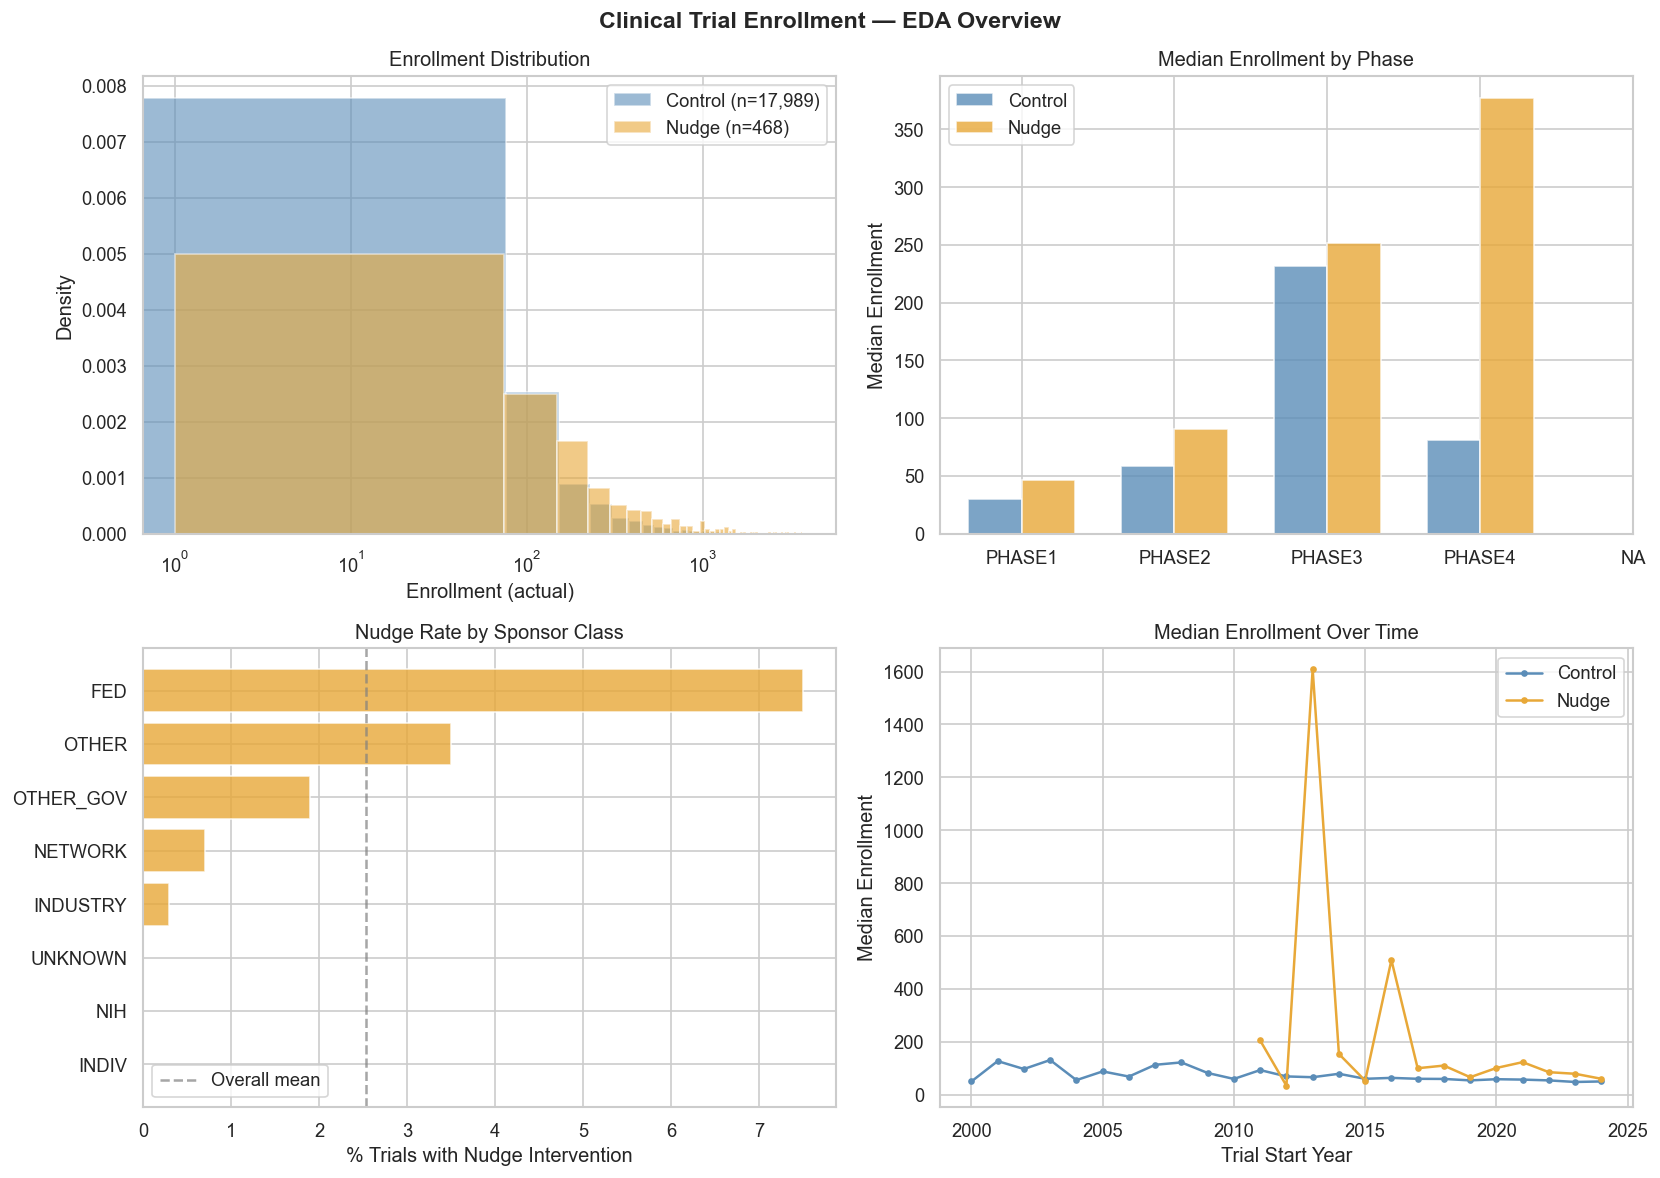

Saved to figures/01_eda_overview.png ✓


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Clinical Trial Enrollment — EDA Overview", fontsize=14, fontweight="bold")

# 1. Enrollment distribution by nudge (log scale)
ax = axes[0, 0]
for val, label, color in [(0, "Control", "#5B8DB8"), (1, "Nudge", "#E8A838")]:
    subset = df_clean[df_clean["has_nudge"] == val]["enrollment_actual"]
    ax.hist(subset, bins=50, alpha=0.6, label=f"{label} (n={len(subset):,})", 
            color=color, density=True)
ax.set_xlabel("Enrollment (actual)")
ax.set_ylabel("Density")
ax.set_title("Enrollment Distribution")
ax.set_xscale("log")
ax.legend()

# 2. Median enrollment by phase
ax = axes[0, 1]
phase_order = ["PHASE1", "PHASE2", "PHASE3", "PHASE4", "NA"]
phase_data = (
    df_clean[df_clean["phase"].isin(phase_order)]
    .groupby(["phase", "has_nudge"])["enrollment_actual"]
    .median()
    .reset_index()
)
phase_data["group"] = phase_data["has_nudge"].map({0: "Control", 1: "Nudge"})
for val, label, color in [(0, "Control", "#5B8DB8"), (1, "Nudge", "#E8A838")]:
    subset = phase_data[phase_data["has_nudge"] == val]
    ax.bar(
        [i + val * 0.35 for i in range(len(subset))],
        subset["enrollment_actual"],
        width=0.35, label=label, color=color, alpha=0.8
    )
ax.set_xticks([i + 0.175 for i in range(len(phase_order))])
ax.set_xticklabels(phase_order)
ax.set_title("Median Enrollment by Phase")
ax.set_ylabel("Median Enrollment")
ax.legend()

# 3. Sponsor class breakdown
ax = axes[1, 0]
sponsor_counts = (
    df_clean.groupby(["sponsor_class", "has_nudge"])
    .size()
    .reset_index(name="count")
)
sponsor_pivot = sponsor_counts.pivot(index="sponsor_class", columns="has_nudge", values="count").fillna(0)
sponsor_pivot.columns = ["Control", "Nudge"]
sponsor_pivot["nudge_pct"] = (sponsor_pivot["Nudge"] / 
                               (sponsor_pivot["Nudge"] + sponsor_pivot["Control"]) * 100).round(1)
sponsor_pivot = sponsor_pivot.sort_values("nudge_pct", ascending=True)
ax.barh(sponsor_pivot.index, sponsor_pivot["nudge_pct"], color="#E8A838", alpha=0.8)
ax.set_xlabel("% Trials with Nudge Intervention")
ax.set_title("Nudge Rate by Sponsor Class")
ax.axvline(x=df_clean["has_nudge"].mean()*100, color="gray", linestyle="--", alpha=0.7, label="Overall mean")
ax.legend()

# 4. Enrollment over time
ax = axes[1, 1]
df_time = df_clean.dropna(subset=["start_date"]).copy()
df_time["year"] = df_time["start_date"].dt.year
yearly = (
    df_time[df_time["year"].between(2000, 2024)]
    .groupby(["year", "has_nudge"])["enrollment_actual"]
    .median()
    .reset_index()
)
for val, label, color in [(0, "Control", "#5B8DB8"), (1, "Nudge", "#E8A838")]:
    subset = yearly[yearly["has_nudge"] == val]
    ax.plot(subset["year"], subset["enrollment_actual"], 
            marker="o", markersize=3, label=label, color=color)
ax.set_title("Median Enrollment Over Time")
ax.set_xlabel("Trial Start Year")
ax.set_ylabel("Median Enrollment")
ax.legend()

plt.tight_layout()
plt.savefig("../figures/01_eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved to figures/01_eda_overview.png ✓")

Sample sizes: nudge=468, control=17,989

Observed means: nudge=307.3, control=151.7
Pooled std    : 318.5
Observed Cohen's d: 0.489

Minimum Detectable Effect (Cohen's d) at 80% power, α=0.05: 0.1312
  → In enrollment units: 41.8 participants


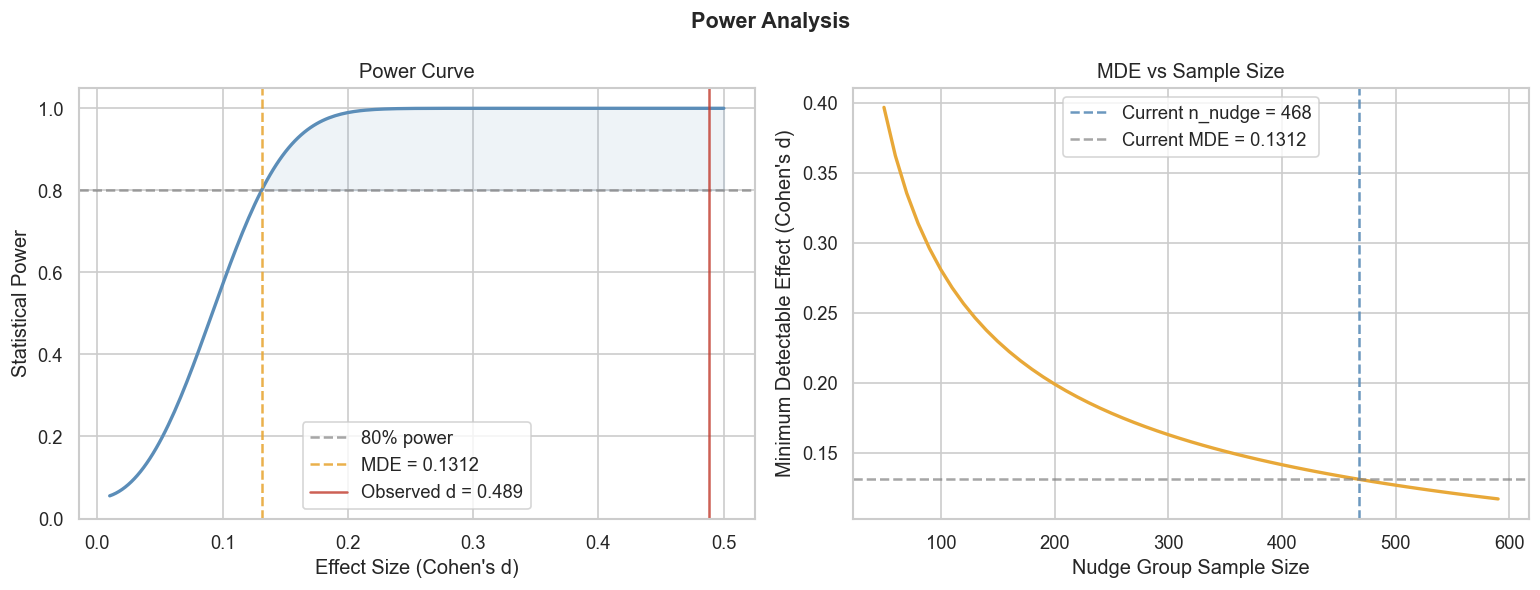

Saved ✓


In [5]:
from scipy.stats import norm

# Current sample sizes
n_nudge = df_clean[df_clean["has_nudge"] == 1]["enrollment_actual"]
n_control = df_clean[df_clean["has_nudge"] == 0]["enrollment_actual"]

n1 = len(n_nudge)
n0 = len(n_control)

print(f"Sample sizes: nudge={n1:,}, control={n0:,}")

# Observed means and pooled std
mean_nudge = n_nudge.mean()
mean_control = n_control.mean()
pooled_std = np.sqrt(
    ((n1 - 1) * n_nudge.std()**2 + (n0 - 1) * n_control.std()**2) / (n1 + n0 - 2)
)

observed_effect = (mean_nudge - mean_control) / pooled_std
print(f"\nObserved means: nudge={mean_nudge:.1f}, control={mean_control:.1f}")
print(f"Pooled std    : {pooled_std:.1f}")
print(f"Observed Cohen's d: {observed_effect:.3f}")

# Power analysis — range of effect sizes
alpha = 0.05
power_target = 0.80
z_alpha = norm.ppf(1 - alpha / 2)  # two-tailed
z_beta  = norm.ppf(power_target)

# MDE given our sample sizes (harmonic mean for unequal groups)
n_harmonic = 2 * n1 * n0 / (n1 + n0)
mde = (z_alpha + z_beta) * np.sqrt(2 / n_harmonic)
print(f"\nMinimum Detectable Effect (Cohen's d) at 80% power, α=0.05: {mde:.4f}")
print(f"  → In enrollment units: {mde * pooled_std:.1f} participants")

# Power curve across effect sizes
effect_sizes = np.linspace(0.01, 0.5, 200)
powers = []
for d in effect_sizes:
    z = d * np.sqrt(n_harmonic / 2)
    power = 1 - norm.cdf(z_alpha - z) + norm.cdf(-z_alpha - z)
    powers.append(power)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Power Analysis", fontsize=13, fontweight="bold")

# Power curve
ax = axes[0]
ax.plot(effect_sizes, powers, color="#5B8DB8", linewidth=2)
ax.axhline(0.80, color="gray", linestyle="--", alpha=0.7, label="80% power")
ax.axvline(mde, color="#E8A838", linestyle="--", alpha=0.9, 
           label=f"MDE = {mde:.4f}")
ax.axvline(observed_effect, color="#C0392B", linestyle="-", alpha=0.8,
           label=f"Observed d = {observed_effect:.3f}")
ax.fill_between(effect_sizes, powers, 0.80, 
                where=[p >= 0.80 for p in powers], alpha=0.1, color="#5B8DB8")
ax.set_xlabel("Effect Size (Cohen's d)")
ax.set_ylabel("Statistical Power")
ax.set_title("Power Curve")
ax.legend()
ax.set_ylim(0, 1.05)

# Sample size sensitivity
ax = axes[1]
nudge_sizes = np.arange(50, 600, 10)
mdes = []
for n in nudge_sizes:
    n_h = 2 * n * n0 / (n + n0)
    mde_i = (z_alpha + z_beta) * np.sqrt(2 / n_h)
    mdes.append(mde_i)

ax.plot(nudge_sizes, mdes, color="#E8A838", linewidth=2)
ax.axvline(n1, color="#5B8DB8", linestyle="--", alpha=0.9,
           label=f"Current n_nudge = {n1}")
ax.axhline(mde, color="gray", linestyle="--", alpha=0.7,
           label=f"Current MDE = {mde:.4f}")
ax.set_xlabel("Nudge Group Sample Size")
ax.set_ylabel("Minimum Detectable Effect (Cohen's d)")
ax.set_title("MDE vs Sample Size")
ax.legend()

plt.tight_layout()
plt.savefig("../figures/02_power_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved ✓")

## Power Analysis

Before running hypothesis tests, we need to verify we have sufficient statistical 
power to detect a meaningful difference in enrollment between nudge and control trials.

**Key parameters:**
- α = 0.05 (two-tailed), target power = 80%
- n_nudge = 468, n_control = 17,989

**Results:**

| Metric | Value |
|---|---|
| Observed mean enrollment — Nudge | 307.3 participants |
| Observed mean enrollment — Control | 151.7 participants |
| Pooled standard deviation | 318.5 |
| Observed Cohen's d | 0.489 (medium effect) |
| Minimum Detectable Effect (MDE) | d = 0.131 (~42 participants) |

**Interpretation:**

Our observed effect size (d=0.489) is nearly **4x larger than our MDE (d=0.131)**, 
meaning we have ample statistical power to detect the observed difference — 
and even effects 4x smaller than what we see in the data.

However, raw enrollment differences do not establish causality. Nudge trials 
may be larger by design (e.g. federal sponsors running large outreach studies), 
not because the nudge itself drives enrollment. The frequentist and Bayesian 
analyses in the next notebooks address this confounding directly.

> **Next:** Notebook 2 — Frequentist A/B testing with multiple testing correction 
> and subgroup analysis.